In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time

Text(0, 0.5, 'Y-axis')

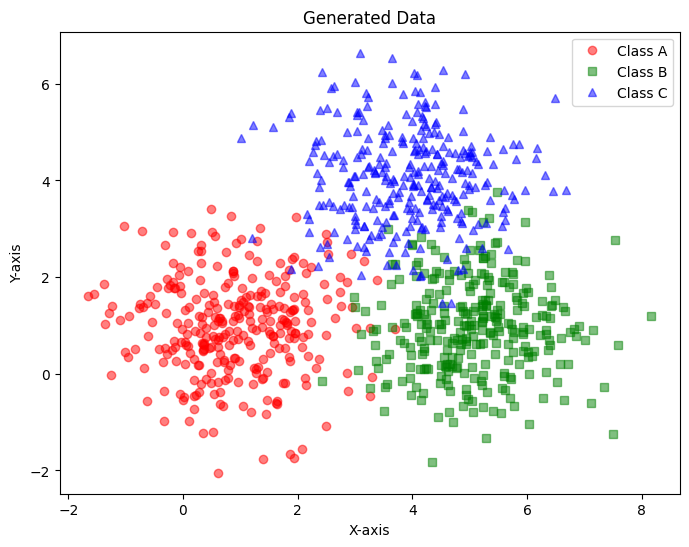

In [23]:
n_points_per_clust = 300
blur = 1

A = [1, 1]
B = [5, 1]
C = [4, 4]

np.random.seed(0)
a = A + np.random.randn(n_points_per_clust, 2)*blur
b = B + np.random.randn(n_points_per_clust, 2)*blur
c = C + np.random.randn(n_points_per_clust, 2)*blur
data_np = np.vstack((a, b, c))
data = torch.from_numpy(data_np).float()

labels_np = np.array([0]*n_points_per_clust + [1]*n_points_per_clust + [2]*n_points_per_clust)
labels = torch.from_numpy(labels_np).long()

fig = plt.figure(figsize=(8, 6))
plt.plot(data[np.where(labels_np == 0)[0], 0], data[np.where(labels_np == 0)[0], 1], 'ro', label='Class A', alpha=0.5)
plt.plot(data[np.where(labels_np == 1)[0], 0], data[np.where(labels_np == 1)[0], 1], 'gs', label='Class B', alpha=0.5)
plt.plot(data[np.where(labels_np == 2)[0], 0], data[np.where(labels_np == 2)[0], 1], 'b^', label='Class C', alpha=0.5)
plt.legend()
plt.title('Generated Data')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

In [28]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.1, random_state=42, stratify=labels)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

print("There are {} batches in the training set.".format(len(train_loader)))

There are 50 batches in the training set.


In [38]:
# create a class for the model
def create_model(input_size, hidden_size, output_size, learning_rate):
    
    class MultiClassNN(nn.Module):
        def __init__(self, input_size, hidden_size, output_size):
            super().__init__()
            self.fc1 = nn.Linear(input_size, hidden_size)
            self.fc2 = nn.Linear(hidden_size, hidden_size)
            self.fc3 = nn.Linear(hidden_size, output_size)

        def forward(self, x):
            x = F.relu(self.fc1(x)) # we can do it like this or instatiate the relu in the __init__ method using self.relu = nn.ReLU() and then call it here using x = self.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x
        
    model = MultiClassNN(input_size, hidden_size, output_size)
    
    loss_fn = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    return model, loss_fn, optimizer

In [39]:
def train_model(model, loss_fn, optimizer, train_loader, test_loader, n_epochs):
    
    losses = torch.zeros(n_epochs)
    train_acc = torch.zeros(n_epochs)
    test_acc = torch.zeros(n_epochs)
    
    for epoch in range(n_epochs):
        model.train()
        
        batch_loss = []
        batch_acc = []
        
        for X_batch, y_batch in train_loader:
            
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            batch_loss.append(loss.item())
            batch_acc_item = (outputs.argmax(dim=1) == y_batch).float().mean().item()
            batch_acc.append(batch_acc_item)

        losses[epoch] = torch.tensor(batch_loss).mean().item()
        train_acc[epoch] = torch.tensor(batch_acc).mean().item()

        model.eval()
        with torch.no_grad():
            X_test, y_test = next(iter(test_loader))
            test_outputs = model(X_test)
            test_acc[epoch] = (test_outputs.argmax(dim=1) == y_test).float().mean().item()

    return losses, train_acc, test_acc

In [40]:
learning_rate = 0.01
n_epochs = 100
model, loss_fn, optimizer = create_model(input_size=2, hidden_size=8, output_size=3, learning_rate=learning_rate)
losses, train_acc, test_acc = train_model(model, loss_fn, optimizer, train_loader, test_loader, n_epochs=n_epochs)

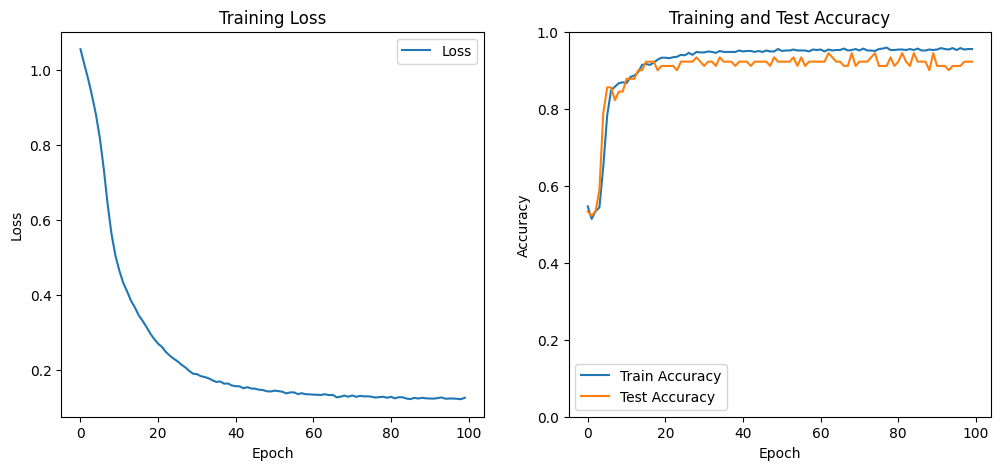

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(losses.numpy(), label='Loss')
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(train_acc.numpy(), label='Train Accuracy')
ax[1].plot(test_acc.numpy(), label='Test Accuracy')
ax[1].set_title('Training and Test Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0, 1)
ax[1].legend()

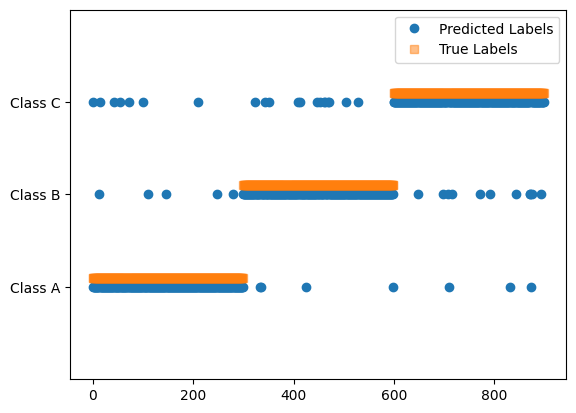

In [ ]:
y_pred = model(data).argmax(dim=1)

plt.plot(y_pred.numpy(), "o", label='Predicted Labels')
plt.plot(labels+.1, "s", label='True Labels', alpha=0.5)
plt.ylim(-1, 3)
plt.yticks([0, 1, 2], ['Class A', 'Class B', 'Class C'])
plt.legend()

# it predicts worse class B than class A for example

Text(0.5, 1.0, 'Overall Accuracy = 95.22%')

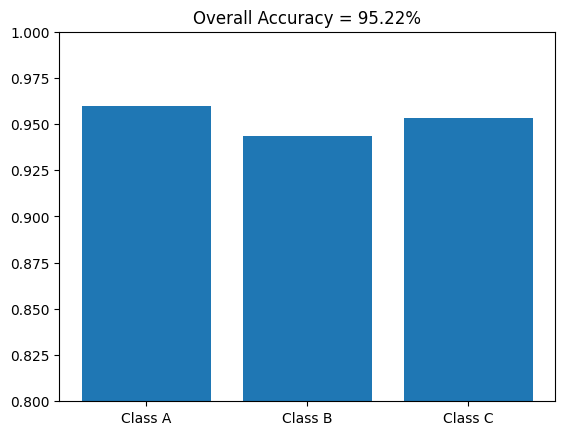

In [63]:
accuracy = (y_pred == labels).float()

accuracy_by_group = np.zeros(3)
for i in range(3):
    accuracy_by_group[i] = torch.mean(accuracy[labels == i]).item()
    
plt.bar(['Class A', 'Class B', 'Class C'], accuracy_by_group)
plt.ylim(0.8, 1)
plt.title('Overall Accuracy = {:.2f}%'.format(accuracy.mean().item()*100))

Text(0, 0.5, 'Y-axis')

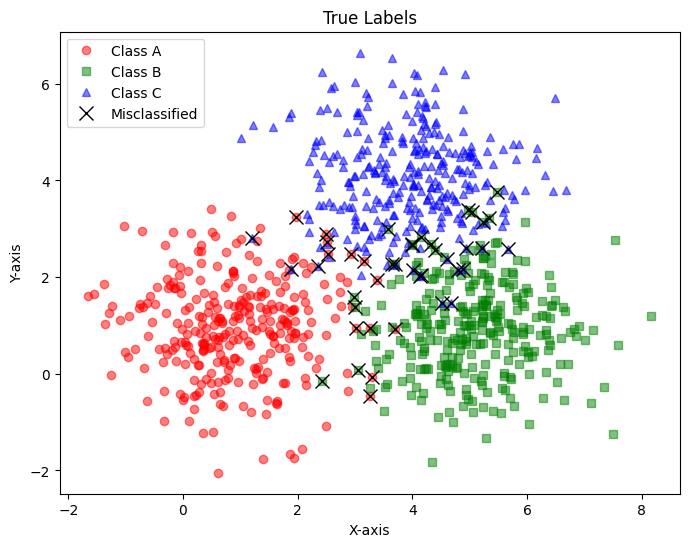

In [68]:
# show true and predicted labels in the same plot to see where the model is making mistakes, show an X where the model is making a mistake
plt.figure(figsize=(8, 6))
plt.plot(data[labels == 0][:, 0], data[labels == 0][:, 1], 'ro', label='Class A', alpha=0.5)
plt.plot(data[labels == 1][:, 0], data[labels == 1][:, 1], 'gs', label='Class B', alpha=0.5)
plt.plot(data[labels == 2][:, 0], data[labels == 2][:, 1], 'b^', label='Class C', alpha=0.5)
plt.plot(data[y_pred != labels][:, 0], data[y_pred != labels][:, 1], 'kx', label='Misclassified', markersize=10)
plt.legend()
plt.title('True Labels')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
